In [149]:
import pandas as pd
import duckdb
import numpy as np

In [150]:
!ls /kaggle/input

steam-dataset-2025-multi-modal-gaming-analytics


In [151]:
BASE_PATH = (
    "/kaggle/input/"
    "steam-dataset-2025-multi-modal-gaming-analytics/"
    "steam_dataset_2025_csv_package_v1/"
    "steam_dataset_2025_csv"
)

import os
os.listdir(BASE_PATH)

['application_platforms.csv',
 'application_publishers.csv',
 'application_genres.csv',
 'MANIFEST.json',
 'genres.csv',
 'categories.csv',
 'reviews.csv',
 'application_categories.csv',
 'developers.csv',
 'applications.csv',
 'publishers.csv',
 'platforms.csv',
 'application_developers.csv']

In [152]:
import pandas as pd

applications = pd.read_csv(f"{BASE_PATH}/applications.csv")
applications.shape

/tmp/ipykernel_55/1212156742.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  applications = pd.read_csv(f"{BASE_PATH}/applications.csv")


(239664, 30)

In [153]:
applications.head()

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_os_min,mat_pc_processor_min,mat_pc_memory_min,mat_pc_graphics_min,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at
0,10,Counter-Strike,game,False,2000-11-01,0,Play the world's number 1 online action game. ...,"English<strong>*</strong>, French<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
1,20,Team Fortress Classic,game,False,1999-04-01,0,One of the most popular online action games of...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
2,30,Day of Defeat,game,False,2003-05-01,0,Enlist in an intense brand of Axis vs. Allied ...,"English, French, German, Italian, Spanish - Spain",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
3,40,Deathmatch Classic,game,False,2001-06-01,0,Enjoy fast-paced multiplayer gaming with Death...,"English, French, German, Italian, Spanish - Sp...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00
4,50,Half-Life: Opposing Force,game,False,1999-11-01,0,Return to the Black Mesa Research Facility as ...,"English, French, German, Korean",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-09-07 16:27:12.218587+00:00,2025-09-29 02:01:37.107239+00:00


In [154]:
applications.columns

Index(['appid', 'name', 'type', 'is_free', 'release_date', 'required_age',
       'short_description', 'supported_languages', 'header_image',
       'background', 'metacritic_score', 'recommendations_total',
       'mat_supports_windows', 'mat_supports_mac', 'mat_supports_linux',
       'mat_initial_price', 'mat_final_price', 'mat_discount_percent',
       'mat_currency', 'mat_achievement_count', 'mat_pc_os_min',
       'mat_pc_processor_min', 'mat_pc_memory_min', 'mat_pc_graphics_min',
       'mat_pc_os_rec', 'mat_pc_processor_rec', 'mat_pc_memory_rec',
       'mat_pc_graphics_rec', 'created_at', 'updated_at'],
      dtype='object')

In [155]:
con = duckdb.connect()

In [156]:
con.execute(f"""
SELECT *
FROM read_csv_auto('{BASE_PATH}/application_genres.csv')
LIMIT 5
""").df()

,appid,genre_id
0,10,122
1,20,122
2,30,122
3,40,122
4,50,122


In [157]:
con.execute(f"""
SELECT *
FROM read_csv_auto('{BASE_PATH}/genres.csv')
LIMIT 5
""").df()

,id,name
0,1,Aventură
1,2,Многопользовательские игры
2,3,Nezávislé
3,4,Strategie
4,5,Strategy


In [158]:
con.execute(f"""
SELECT
    ag.appid,
    string_agg(g.name, ', ') AS genres
FROM read_csv_auto('{BASE_PATH}/application_genres.csv') ag
JOIN read_csv_auto('{BASE_PATH}/genres.csv') g
    ON ag.genre_id = g.id
GROUP BY ag.appid
LIMIT 5
""").df()

,appid,genres
0,1502,"Strategy, Indie"
1,2850,"Strategy, Simulation"
2,3612,Casual
3,3810,Action
4,6020,Action


the above code need to be removed

In [159]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW app_genres AS
SELECT
    ag.appid,
    string_agg(g.name, ', ') AS genres
FROM read_csv_auto('{BASE_PATH}/application_genres.csv') ag
JOIN read_csv_auto('{BASE_PATH}/genres.csv') g
    ON ag.genre_id = g.id
GROUP BY ag.appid
""")

In [160]:
con.execute(f"""
SELECT *
FROM read_csv_auto('{BASE_PATH}/application_categories.csv')
LIMIT 5
""").df()

,appid,category_id
0,10,72
1,10,90
2,10,130
3,10,133
4,10,193


In [161]:
con.execute(f"""
SELECT *
FROM read_csv_auto('{BASE_PATH}/categories.csv')
LIMIT 5
""").df()

,id,name
0,1,Remote Play en móvil
1,2,Flera spelare
2,3,Tablette Remote Play
3,4,Multiplayer
4,5,Таблицы лидеров Steam


In [162]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW app_categories AS
SELECT
    ac.appid,
    string_agg(c.name, ', ') AS categories
FROM read_csv_auto('{BASE_PATH}/application_categories.csv') ac
JOIN read_csv_auto('{BASE_PATH}/categories.csv') c
    ON ac.category_id = c.id
GROUP BY ac.appid
""")

In [163]:
con.execute("""
SELECT *
FROM app_categories
LIMIT 5
""").df()

,appid,categories
0,2458580,"Steam Achievements, Family Sharing, Single-player"
1,2458760,"Single-player, Downloadable Content"
2,2459190,"Steam Achievements, Family Sharing, Single-player"
3,2459270,"Family Sharing, Single-player"
4,2459820,"Family Sharing, Single-player, Partial Control..."


In [164]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW app_developers AS
SELECT
    ad.appid,
    string_agg(DISTINCT d.name, ', ') AS developers
FROM read_csv_auto('{BASE_PATH}/application_developers.csv') ad
JOIN read_csv_auto('{BASE_PATH}/developers.csv') d
    ON ad.developer_id = d.id
GROUP BY ad.appid
""")

In [165]:
con.execute("""
SELECT *
FROM app_developers
LIMIT 5
""").df()

,appid,developers
0,47899,The Sims Studio
1,113420,Little Orbit
2,218550,"Gearbox Software, Aspyr (Mac), Aspyr (Linux)"
3,231470,"Feral Interactive (Mac), Relic Entertainment, ..."
4,249590,Rain Games


In [166]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW app_publishers AS
SELECT
    ap.appid,
    string_agg(DISTINCT p.name, ', ') AS publishers
FROM read_csv_auto('{BASE_PATH}/application_publishers.csv') ap
JOIN read_csv_auto('{BASE_PATH}/publishers.csv') p
    ON ap.publisher_id = p.id
GROUP BY ap.appid
""")

In [167]:
con.execute("""
SELECT *
FROM app_publishers
LIMIT 5
""").df()

,appid,publishers
0,4900,Unknown Worlds Entertainment
1,99120,Atari
2,206060,Spiderweb Software
3,259251,Activision
4,260291,"Feral Interactive (Linux), Feral Interactive (..."


In [168]:
con.execute(f"""
CREATE OR REPLACE TABLE applications_wide AS
SELECT
    a.*,
    g.genres,
    c.categories,
    d.developers,
    p.publishers
FROM read_csv_auto(
        '{BASE_PATH}/applications.csv',
        ignore_errors=true
     ) a
LEFT JOIN app_genres g      ON a.appid = g.appid
LEFT JOIN app_categories c  ON a.appid = c.appid
LEFT JOIN app_developers d  ON a.appid = d.appid
LEFT JOIN app_publishers p  ON a.appid = p.appid
""")

In [169]:
con.execute("""
SELECT COUNT(*) FROM applications_wide
""").df()

,count_star()
0,239653


In [170]:
con.execute("""
SELECT * FROM applications_wide LIMIT 5
""").df()

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_os_rec,mat_pc_processor_rec,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at,genres,categories,developers,publishers
0,670490,Rise of Man,game,False,2017-09-15,0,Rise of Man is a pre historic strategy game wi...,"English<strong>*</strong>, Simplified Chinese<...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,Windows 7 / Windows 8,Intel Core i5 processor (or greater) 64bit,8 GB RAM,512 MB DirectX 10 compatible card,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:07.947948+00:00,"Strategy, Simulation, Indie, Early Access","Family Sharing, Single-player",Darkcross Games,Darkcross Games
1,670500,RC Plane 3,game,True,2017-08-07,0,Learn to fly a large selection of RC Planes in...,English<strong>*</strong><br><strong>*</strong...,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:14.546455+00:00,"Simulation, Racing, Sports","Steam Achievements, PvP, Cross-Platform Multip...",FrozenPepper S.R.L,FrozenPepper S.R.L.
2,670510,ColorBlend FX: Desaturation,game,False,2024-04-18,0,Help Splatians blend the stolen colors back wi...,"English<strong>*</strong>, Bulgarian, Simplifi...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,Windows 10,i5 6th generation or new,8 GB RAM,nVidia GeForce GTX 1060 and up / AMD RX 580 an...,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:45.421414+00:00,"Indie, Adventure, Action","Steam Achievements, Full controller support, F...",Pi-Dev Bulgaria,Pi-Dev Bulgaria
3,670550,Light Biker Hockey,game,False,NaT,0,Do you like motorbikes and hockey too? Than th...,English<strong>*</strong><br><strong>*</strong...,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,None,None,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:12.010655+00:00,"Racing, Sports, Adventure","PvP, In-App Purchases, Cross-Platform Multipla...",Theodor Niklas,Theodor Niklas
4,670560,3D MiniGolf: Candy Shop,dlc,True,2017-10-09,0,New DLC &quot;Candy Shopf&quot; available! Sug...,"English<strong>*</strong>, German<strong>*</st...",https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,10.8,2 GHz Intel-based and above,2 GB RAM,256 MB RAM required,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:02:12.010655+00:00,"Simulation, Casual, Sports","Steam Achievements, Family Sharing, Single-pla...",Z-Software GmbH,familyplay


In [171]:
df = con.execute("""
SELECT *
FROM applications_wide
""").df()

df.shape

(239653, 34)

In [172]:
df.to_csv("/kaggle/working/applications_wide.csv", index=False)

In [173]:
con.execute(f"""
SELECT DISTINCT recommendationid
FROM read_csv_auto('{BASE_PATH}/reviews.csv')
LIMIT 10
""").df()

,recommendationid
0,112103076
1,112103166
2,112108983
3,11211473
4,112138376
5,112145347
6,11214656
7,112153833
8,112161864
9,112169964


In [174]:
con.execute(f"""
CREATE OR REPLACE TEMP VIEW reviews_aggregated AS
SELECT
    appid,
    COUNT(*) AS n_reviews,

    -- sentiment
    SUM(CASE WHEN voted_up THEN 1 ELSE 0 END) AS positive_reviews,
    SUM(CASE WHEN NOT voted_up THEN 1 ELSE 0 END) AS negative_reviews,

    -- engagement (correct column)
    AVG(author_playtime_forever) AS avg_playtime,

    -- review usefulness
    AVG(votes_up) AS avg_helpful_votes

FROM read_csv_auto(
    '{BASE_PATH}/reviews.csv',
    ignore_errors=true
)
GROUP BY appid
""")


In [175]:
df1 = con.execute("""
SELECT * 
FROM reviews_aggregated
""").df()
df1.shape

(117311, 6)

In [176]:
df1.to_csv("/kaggle/working/reviews_wide.csv", index=False)

In [177]:
con.execute("""
SELECT *
FROM reviews_aggregated
LIMIT 10
""").df()

,appid,n_reviews,positive_reviews,negative_reviews,avg_playtime,avg_helpful_votes
0,250640,100,76.0,24.0,431.160000,4.690000
1,1186290,54,23.0,31.0,514.962963,6.462963
2,1082890,64,39.0,25.0,182.750000,4.984375
3,344100,8,3.0,5.0,356.125000,5.125000
4,695980,12,10.0,2.0,433.500000,2.500000
5,915590,17,16.0,1.0,0.000000,1.764706
6,1610880,11,8.0,3.0,0.000000,9.090909
7,1582160,3,3.0,0.0,1574.333333,0.000000
8,280830,100,58.0,42.0,215.180000,3.470000
9,1181300,16,15.0,1.0,111.562500,0.812500


In [178]:
con.execute("""
CREATE OR REPLACE TABLE applications_wide_with_reviews AS
SELECT
    a.*,

    -- review volume
    r.n_reviews,
    -- engagement
    r.avg_playtime,

FROM applications_wide a
LEFT JOIN reviews_aggregated r
    ON a.appid = r.appid
""")

In [179]:
con.execute("""
SELECT *
FROM applications_wide_with_reviews
LIMIT 3
""").df()

,appid,name,type,is_free,release_date,required_age,short_description,supported_languages,header_image,background,...,mat_pc_memory_rec,mat_pc_graphics_rec,created_at,updated_at,genres,categories,developers,publishers,n_reviews,avg_playtime
0,1663370,Erotic Jigsaw Puzzle 4,game,False,2021-06-17,0,Challenging 6 x 6 jigsaw puzzles featuring har...,English,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,None,None,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:25.906520+00:00,"Indie, Casual","Steam Achievements, Family Sharing, Single-pla...",EGC Games,EGC Games,10,46.900000
1,1677620,TurBot,game,False,2021-07-29,0,"TurBot is a fast-paced, hard as nails race to ...",English,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,4 GB RAM,GeForce GTX 1080,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:03:07.926107+00:00,"Racing, Indie, Action","Family Sharing, Single-player, Steam Leaderboards",Jacob Moore,Igloo Games LLC,9,1923.666667
2,1814990,不充钱还想过关的坦克大战？,game,False,2021-12-15,0,《不充钱还想过关的坦克大战？》是一款2D俯视射击游戏，拥有众多升级与强化方案供玩家探索，同时...,Simplified Chinese<strong>*</strong><br><stron...,https://shared.akamai.steamstatic.com/store_it...,https://store.akamai.steamstatic.com/images/st...,...,4 GB RAM,GTX 1060,2025-09-07 12:36:43.243384+00:00,2025-09-29 06:04:20.044396+00:00,"Indie, Casual","Family Sharing, Single-player","四元方程, 魁米乐游戏","四元方程, 魁米乐游戏",17,606.588235


In [180]:
df = con.execute("""
SELECT *
FROM applications_wide_with_reviews
""").df()

df.shape

(239653, 36)

In [181]:
df.to_csv("/kaggle/working/applications_wide_with_reviews.csv", index=False)

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239653 entries, 0 to 239652
Data columns (total 36 columns):
 #   Column                 Non-Null Count   Dtype                  
---  ------                 --------------   -----                  
 0   appid                  239653 non-null  int64                  
 1   name                   239653 non-null  object                 
 2   type                   236986 non-null  object                 
 3   is_free                239653 non-null  bool                   
 4   release_date           202799 non-null  datetime64[us]         
 5   required_age           239653 non-null  int64                  
 6   short_description      224162 non-null  object                 
 7   supported_languages    221995 non-null  object                 
 8   header_image           239653 non-null  object                 
 9   background             239653 non-null  object                 
 10  metacritic_score       5298 non-null    float64         

**Till now, we have done denormalization and have created a master table to perform EDA**

**CHEKING NULL VALUES IN THE COLUMNS**

In [183]:
missing_pct =df.isna().mean().sort_values(ascending=False)
missing_pct.head(40)

metacritic_score         0.977893
recommendations_total    0.905872
mat_achievement_count    0.743800
mat_pc_graphics_rec      0.615294
mat_pc_memory_rec        0.595987
mat_pc_processor_rec     0.594772
mat_pc_os_rec            0.574568
avg_playtime             0.510534
n_reviews                0.510534
mat_final_price          0.395309
mat_discount_percent     0.395309
mat_initial_price        0.395309
mat_currency             0.395309
mat_pc_graphics_min      0.291910
mat_pc_memory_min        0.243606
mat_pc_processor_min     0.234639
mat_pc_os_min            0.182097
release_date             0.153781
genres                   0.132366
publishers               0.105536
supported_languages      0.073682
short_description        0.064639
categories               0.058422
developers               0.044581
type                     0.011129
is_free                  0.000000
appid                    0.000000
name                     0.000000
mat_supports_mac         0.000000
mat_supports_w

In [184]:
df.isnull().sum().sort_values(ascending=False)

metacritic_score         234355
recommendations_total    217095
mat_achievement_count    178254
mat_pc_graphics_rec      147457
mat_pc_memory_rec        142830
mat_pc_processor_rec     142539
mat_pc_os_rec            137697
avg_playtime             122351
n_reviews                122351
mat_final_price           94737
mat_discount_percent      94737
mat_initial_price         94737
mat_currency              94737
mat_pc_graphics_min       69957
mat_pc_memory_min         58381
mat_pc_processor_min      56232
mat_pc_os_min             43640
release_date              36854
genres                    31722
publishers                25292
supported_languages       17658
short_description         15491
categories                14001
developers                10684
type                       2667
is_free                       0
appid                         0
name                          0
mat_supports_mac              0
mat_supports_windows          0
mat_supports_linux            0
header_i

**DROPPING BELOW MENTIONED COLUMNS**

mat_achievement_count :- Missing for most apps; weak explanatory power

mat_pc_graphics_rec :- 60% missing; free-text and non-standardized

mat_pc_memory_rec :-  60% missing; free-text and non-standardized

mat_pc_processor_rec :- 60% missing; free-text and non-standardized

mat_pc_os_rec :- 60% missing; free-text and non-standardized

mat_currency :- value is same for all the rowws, can be ignored

mat_pc_graphics_min :- missing values
mat_pc_memory_min         58381
mat_pc_processor_min      56232
mat_pc_os_min             43640



Descriptions (about_the_game, short_description) Text analysis out of EDA scope

Images / URLs (header_image, background) Non-analytical

Language lists High cardinality and noisy

Operational timestamps (created_at, updated_at) Do not explain user behavior


In [185]:
eda_cols = [
    # identifiers
    'appid', 'name',

    # metadata
    'type', 'is_free', 'required_age', 'release_date',

    # pricing
    'mat_initial_price', 'mat_final_price', 'mat_discount_percent', 'mat_currency',

    # content
    'genres', 'categories', 'developers', 'publishers',

    # external / reputation signals (sparse but useful)
    'metacritic_score',
    'recommendations_total',

    # sentiment (core)
    'n_reviews',

    # engagement
    'avg_playtime',

    # platforms
    'mat_supports_windows', 'mat_supports_linux', 'mat_supports_mac'
]

df_eda = df[eda_cols]
df_eda.shape

(239653, 21)

In [186]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 239653 entries, 0 to 239652
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  239653 non-null  int64         
 1   name                   239653 non-null  object        
 2   type                   236986 non-null  object        
 3   is_free                239653 non-null  bool          
 4   required_age           239653 non-null  int64         
 5   release_date           202799 non-null  datetime64[us]
 6   mat_initial_price      144916 non-null  float64       
 7   mat_final_price        144916 non-null  float64       
 8   mat_discount_percent   144916 non-null  float64       
 9   mat_currency           144916 non-null  object        
 10  genres                 207931 non-null  object        
 11  categories             225652 non-null  object        
 12  developers             228969 non-null  obje

In [187]:
df_eda.isnull().sum().sort_values(ascending=False)

metacritic_score         234355
recommendations_total    217095
avg_playtime             122351
n_reviews                122351
mat_initial_price         94737
mat_discount_percent      94737
mat_final_price           94737
mat_currency              94737
release_date              36854
genres                    31722
publishers                25292
categories                14001
developers                10684
type                       2667
is_free                       0
name                          0
appid                         0
required_age                  0
mat_supports_windows          0
mat_supports_linux            0
mat_supports_mac              0
dtype: int64

In [188]:
df_eda['is_free'].value_counts(dropna=False)

is_free
False    191381
True      48272
Name: count, dtype: int64

In [189]:
df_eda1 = df[eda_cols].copy()

In [190]:
import pandas as pd

# Ensure datetime
df_eda1['release_date'] = pd.to_datetime(df_eda1['release_date'], errors='coerce')

start_date = pd.Timestamp('1969-12-31')
end_date   = pd.Timestamp('2026-01-23')

# Rows NOT in the range (including NULLs)
rows_outside = df_eda1[
    df_eda1['release_date'].isna() |
    (df_eda1['release_date'] < start_date) |
    (df_eda1['release_date'] > end_date)
]

rows_outside_count = rows_outside.shape[0]
rows_outside_count

37025

In [191]:
import pandas as pd

# Ensure release_date is datetime
df_eda1['release_date'] = pd.to_datetime(df_eda1['release_date'], errors='coerce')

# Define valid date range
start_date = pd.Timestamp('1969-12-31')
end_date   = pd.Timestamp('2026-01-23')

# Drop null and out-of-range dates
df_eda1 = df_eda1[
    df_eda1['release_date'].notna() &
    (df_eda1['release_date'] >= start_date) &
    (df_eda1['release_date'] <= end_date)
].copy()

In [192]:
# Rows NOT in the range (including NULLs)
rows_outside = df_eda1[
    df_eda1['release_date'].isna() |
    (df_eda1['release_date'] < start_date) |
    (df_eda1['release_date'] > end_date)
]

rows_outside_count = rows_outside.shape[0]
rows_outside_count

0

In [193]:
df_eda1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202628 entries, 0 to 239651
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  202628 non-null  int64         
 1   name                   202628 non-null  object        
 2   type                   200028 non-null  object        
 3   is_free                202628 non-null  bool          
 4   required_age           202628 non-null  int64         
 5   release_date           202628 non-null  datetime64[us]
 6   mat_initial_price      144519 non-null  float64       
 7   mat_final_price        144519 non-null  float64       
 8   mat_discount_percent   144519 non-null  float64       
 9   mat_currency           144519 non-null  object        
 10  genres                 171903 non-null  object        
 11  categories             188987 non-null  object        
 12  developers             192099 non-null  object   

In [194]:
df_eda1.isnull().sum().sort_values(ascending=False)

metacritic_score         197384
recommendations_total    180263
avg_playtime              85811
n_reviews                 85811
mat_initial_price         58109
mat_discount_percent      58109
mat_final_price           58109
mat_currency              58109
genres                    30725
publishers                24703
categories                13641
developers                10529
type                       2600
required_age                  0
is_free                       0
name                          0
appid                         0
release_date                  0
mat_supports_windows          0
mat_supports_linux            0
mat_supports_mac              0
dtype: int64

In [195]:
df_eda1['mat_currency'].dropna().unique()

array(['USD', 'AUD', 'PHP', 'INR', 'MYR', 'EUR', 'VND', 'RUB', 'PLN',
       'AED', 'HKD', 'GBP', 'CAD', 'IDR', 'THB', 'ILS', 'SGD', 'BRL',
       'CNY', 'CLP', 'KRW', 'MXN', 'JPY', 'NOK', 'CHF', 'COP', 'SAR',
       'ZAR', 'TWD', 'UYU', 'NZD'], dtype=object)


**We are converting prices to USD using approximate mid-market exchange rates to enable consistent exploratory analysis. Exact historical exchange rates were not used as the objective was relative price comparison rather than financial accuracy**

In [196]:
import pandas as pd

# Ensure price columns are numeric
df_eda1['mat_initial_price'] = pd.to_numeric(
    df_eda1['mat_initial_price'], errors='coerce'
)
df_eda1['mat_final_price'] = pd.to_numeric(
    df_eda1['mat_final_price'], errors='coerce'
)

# Exchange rates to USD
exchange_rates_to_usd = {
    'USD': 1.0, 'PHP': 0.018, 'VND': 0.000041, 'AUD': 0.66, 'INR': 0.012,
    'MYR': 0.21, 'EUR': 1.08, 'CAD': 0.74, 'SGD': 0.74, 'RUB': 0.011,
    'PLN': 0.25, 'GBP': 1.27, 'ILS': 0.27, 'IDR': 0.000064, 'HKD': 0.13,
    'BRL': 0.20, 'AED': 0.27, 'THB': 0.028, 'CNY': 0.14, 'KRW': 0.00075,
    'JPY': 0.0068, 'CLP': 0.0011, 'MXN': 0.059, 'UYU': 0.026, 'CHF': 1.11,
    'NOK': 0.094, 'SAR': 0.27, 'COP': 0.00025, 'ZAR': 0.054,
    'TWD': 0.032, 'NZD': 0.61
}

# Convert both prices to USD
df_eda1['mat_initial_price'] = (
    df_eda1['mat_initial_price'] *
    df_eda1['mat_currency'].map(exchange_rates_to_usd)
)

df_eda1['mat_final_price'] = (
    df_eda1['mat_final_price'] *
    df_eda1['mat_currency'].map(exchange_rates_to_usd)
)

# Set currency to USD where conversion happened
df_eda1.loc[
    df_eda1[['mat_initial_price', 'mat_final_price']].notna().any(axis=1),
    'mat_currency'
] = 'USD'

In [197]:
# Currency should now be only USD
df_eda1['mat_currency'].value_counts()

mat_currency
USD    144519
Name: count, dtype: int64

In [198]:
# Price ranges should look reasonable
df_eda1[['mat_initial_price', 'mat_final_price']].describe()

,mat_initial_price,mat_final_price
count,144519.00000,144519.000000
mean,919.72727,858.305096
std,1593.68971,1516.751053
min,33.00000,23.100000
25%,299.00000,250.000000
50%,499.00000,499.000000
75%,999.00000,999.000000
max,190000.00000,190000.000000


In [199]:
cat_cols = ['type','genres', 'publishers', 'categories', 'developers', 'mat_currency']
df_eda1.loc[:, cat_cols] = df_eda1[cat_cols].fillna('Others')

In [200]:
df_eda1.isnull().sum().sort_values(ascending=False)

metacritic_score         197384
recommendations_total    180263
avg_playtime              85811
n_reviews                 85811
mat_initial_price         58109
mat_discount_percent      58109
mat_final_price           58109
required_age                  0
name                          0
appid                         0
is_free                       0
type                          0
release_date                  0
developers                    0
categories                    0
genres                        0
mat_currency                  0
publishers                    0
mat_supports_windows          0
mat_supports_linux            0
mat_supports_mac              0
dtype: int64

In [201]:
df_eda1['is_free'].value_counts(dropna=False)

is_free
False    158587
True      44041
Name: count, dtype: int64

In [202]:
# Convert is_free to True where initial price is NULL
df_eda1.loc[
    (df_eda1['is_free'] == False) &
    (df_eda1['mat_initial_price'].isna()),
    'is_free'
] = True


In [203]:
# Set prices to 0 for newly marked free games
df_eda1.loc[
    df_eda1['is_free'] == True,
    ['mat_initial_price', 'mat_final_price']
] = 0

# Set discount to 0 for free games
df_eda1.loc[
    df_eda1['is_free'] == True,
    'mat_discount_percent'
] = 0

In [204]:
df_eda1.loc[df_eda1['is_free'] == False, 'mat_initial_price'].isna().sum()

np.int64(0)

In [205]:
df_eda1['is_free'].value_counts()

is_free
False    144519
True      58109
Name: count, dtype: int64

In [206]:
df_eda1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202628 entries, 0 to 239651
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  202628 non-null  int64         
 1   name                   202628 non-null  object        
 2   type                   202628 non-null  object        
 3   is_free                202628 non-null  bool          
 4   required_age           202628 non-null  int64         
 5   release_date           202628 non-null  datetime64[us]
 6   mat_initial_price      202628 non-null  float64       
 7   mat_final_price        202628 non-null  float64       
 8   mat_discount_percent   202628 non-null  float64       
 9   mat_currency           202628 non-null  object        
 10  genres                 202628 non-null  object        
 11  categories             202628 non-null  object        
 12  developers             202628 non-null  object   

In [207]:
df_eda1.isnull().sum().sort_values(ascending=False)

metacritic_score         197384
recommendations_total    180263
avg_playtime              85811
n_reviews                 85811
appid                         0
required_age                  0
is_free                       0
type                          0
name                          0
release_date                  0
mat_initial_price             0
mat_final_price               0
mat_discount_percent          0
developers                    0
categories                    0
genres                        0
mat_currency                  0
publishers                    0
mat_supports_windows          0
mat_supports_linux            0
mat_supports_mac              0
dtype: int64

In [208]:
price_cols = ['n_reviews','metacritic_score','recommendations_total','avg_playtime']
df_eda1[price_cols] = df_eda1[price_cols].fillna(0)

In [209]:
df_eda1.isnull().sum().sort_values(ascending=False)

appid                    0
name                     0
type                     0
is_free                  0
required_age             0
release_date             0
mat_initial_price        0
mat_final_price          0
mat_discount_percent     0
mat_currency             0
genres                   0
categories               0
developers               0
publishers               0
metacritic_score         0
recommendations_total    0
n_reviews                0
avg_playtime             0
mat_supports_windows     0
mat_supports_linux       0
mat_supports_mac         0
dtype: int64

In [210]:
df_eda1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202628 entries, 0 to 239651
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  202628 non-null  int64         
 1   name                   202628 non-null  object        
 2   type                   202628 non-null  object        
 3   is_free                202628 non-null  bool          
 4   required_age           202628 non-null  int64         
 5   release_date           202628 non-null  datetime64[us]
 6   mat_initial_price      202628 non-null  float64       
 7   mat_final_price        202628 non-null  float64       
 8   mat_discount_percent   202628 non-null  float64       
 9   mat_currency           202628 non-null  object        
 10  genres                 202628 non-null  object        
 11  categories             202628 non-null  object        
 12  developers             202628 non-null  object   

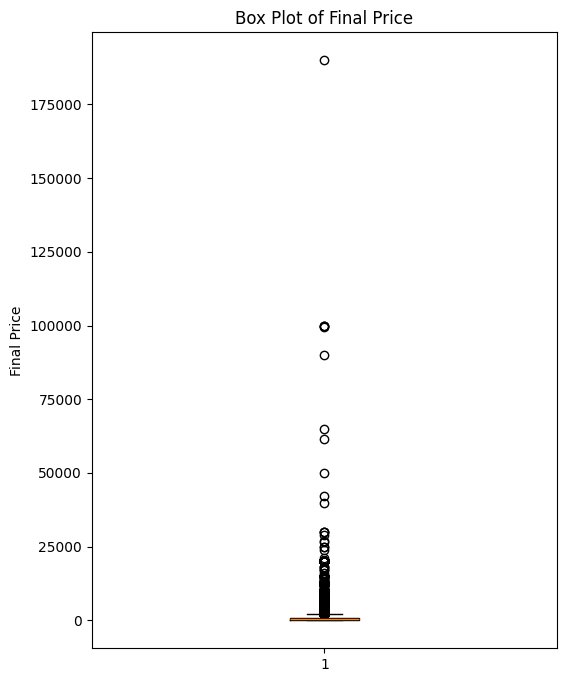

In [211]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure numeric
df_eda1['mat_final_price'] = pd.to_numeric(
    df_eda1['mat_final_price'], errors='coerce')

plt.figure(figsize=(6,8))
plt.boxplot(df_eda1['mat_final_price'].dropna())
plt.ylabel("Final Price")
plt.title("Box Plot of Final Price")
plt.show()

In [212]:
Q1 = df_eda1['mat_final_price'].quantile(0.25)
Q3 = df_eda1['mat_final_price'].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
upper_limit


np.float64(1997.5)

In [213]:
df_eda1.shape[0]

202628

In [214]:
paid_prices = df_eda1.loc[
    (df_eda1['is_free'] == False) &
    (df_eda1['mat_final_price'] > 0),
    'mat_final_price'
]

Q1 = paid_prices.quantile(0.25)
Q3 = paid_prices.quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
upper_limit

np.float64(2122.5)

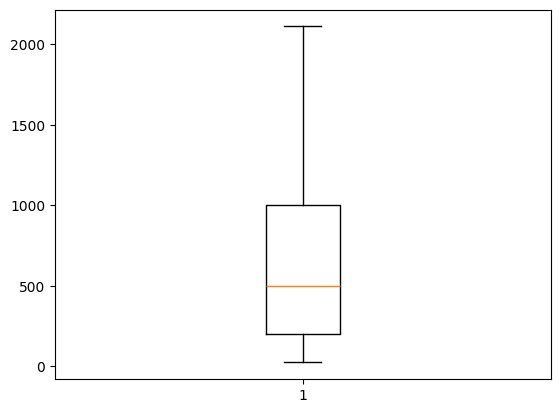

In [215]:
price_for_plot = df_eda1[
    (df_eda1['is_free'] == False) &
    (df_eda1['mat_final_price'] > 0) &
    (df_eda1['mat_final_price'] <= upper_limit)
]

plt.boxplot(price_for_plot['mat_final_price'])
plt.show()

In [216]:
paid_prices = df_eda1.loc[
    (df_eda1['is_free'] == False) &
    (df_eda1['mat_initial_price'] > 0),
    'mat_initial_price'
]

Q1 = paid_prices.quantile(0.25)
Q3 = paid_prices.quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR
upper_limit

np.float64(2049.0)

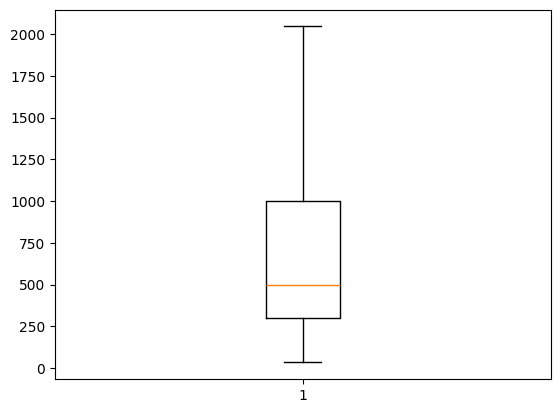

In [217]:
price_for_plot = df_eda1[
    (df_eda1['is_free'] == False) &
    (df_eda1['mat_initial_price'] > 0) &
    (df_eda1['mat_initial_price'] <= upper_limit)
]

plt.boxplot(price_for_plot['mat_initial_price'])
plt.show()

In [218]:
# Store row count before
rows_before = df_eda1.shape[0]

# Drop rows where price > 2122
df_final = df_eda1[
    df_eda1['mat_initial_price'].notna() &
    (df_eda1['mat_initial_price'] <= 2050)
].copy()

# Store row count after
rows_after = df_final.shape[0]

print(f"Rows before: {rows_before}")
print(f"Rows after:  {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")

Rows before: 202628
Rows after:  192536
Rows dropped: 10092


In [219]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202628 entries, 0 to 239651
Data columns (total 21 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   appid                  202628 non-null  int64         
 1   name                   202628 non-null  object        
 2   type                   202628 non-null  object        
 3   is_free                202628 non-null  bool          
 4   required_age           202628 non-null  int64         
 5   release_date           202628 non-null  datetime64[us]
 6   mat_initial_price      202628 non-null  float64       
 7   mat_final_price        202628 non-null  float64       
 8   mat_discount_percent   202628 non-null  float64       
 9   mat_currency           202628 non-null  object        
 10  genres                 202628 non-null  object        
 11  categories             202628 non-null  object        
 12  developers             202628 non-null  object   

In [220]:
df_final['required_age'].value_counts().sort_index()

required_age
0     189301
1          5
3          7
5          1
6          5
7         11
8          1
10        46
11         3
12        41
13       413
14        24
15         7
16        64
17      2124
18       480
20         1
21         2
Name: count, dtype: int64

In [221]:
# Apply PEGI-style bucketing
df_final['required_age'] = np.select(
    [
        df_final['required_age'] == 0,
        df_final['required_age'].between(1, 3),
        df_final['required_age'].between(4, 7),
        df_final['required_age'].between(8, 12),
        df_final['required_age'].between(13, 16),
        df_final['required_age'] >= 17
    ],
    [
        0,   # No age restriction
        3,   # PEGI 3
        7,   # PEGI 7
        12,  # PEGI 12
        16,  # PEGI 16
        18   # PEGI 18
    ],
    default=np.nan
)

In [222]:
df_final['required_age'] = df_final['required_age'].astype('Int64')
df_final['required_age'].value_counts().sort_index()

required_age
0     189301
3         12
7         17
12        91
16       508
18      2607
Name: count, dtype: Int64

In [223]:
df_final.to_csv("/kaggle/working/final_eda_done.csv", index=False)